In [17]:
library(tidyr)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
ff48 <- read.csv("../../data/ff48/ff48_546months.csv")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  17.44   34.57   42.98   59.07   55.18  682.97 

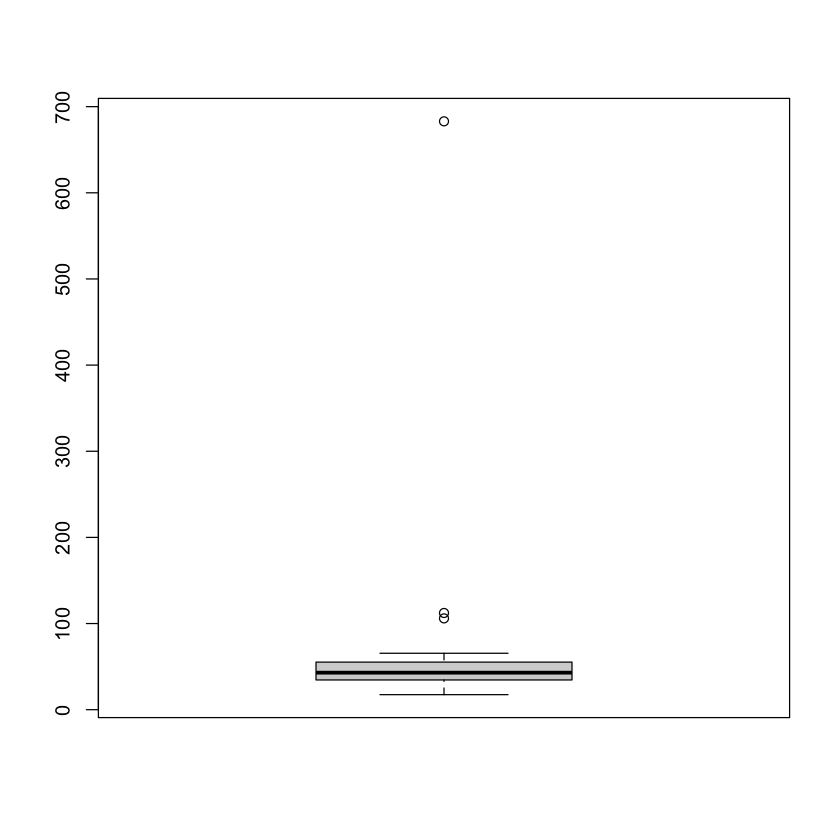

In [14]:
summary(apply(ff48, 2, var))
boxplot(apply(ff48, 2, var)) # one of the stocks has an exremely large variance ... thist stock will be removed

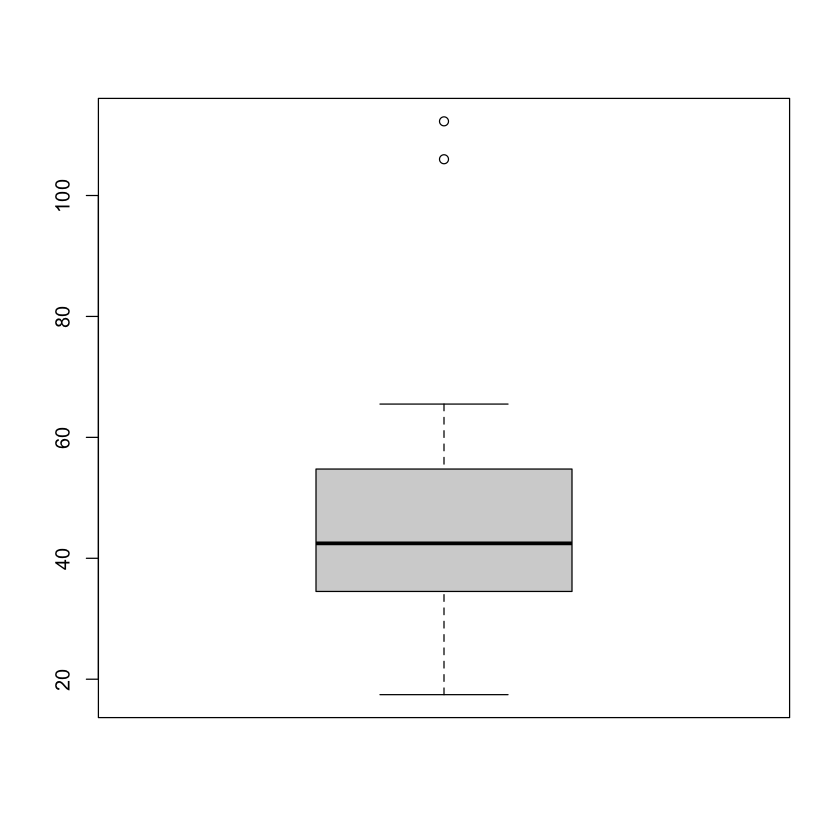

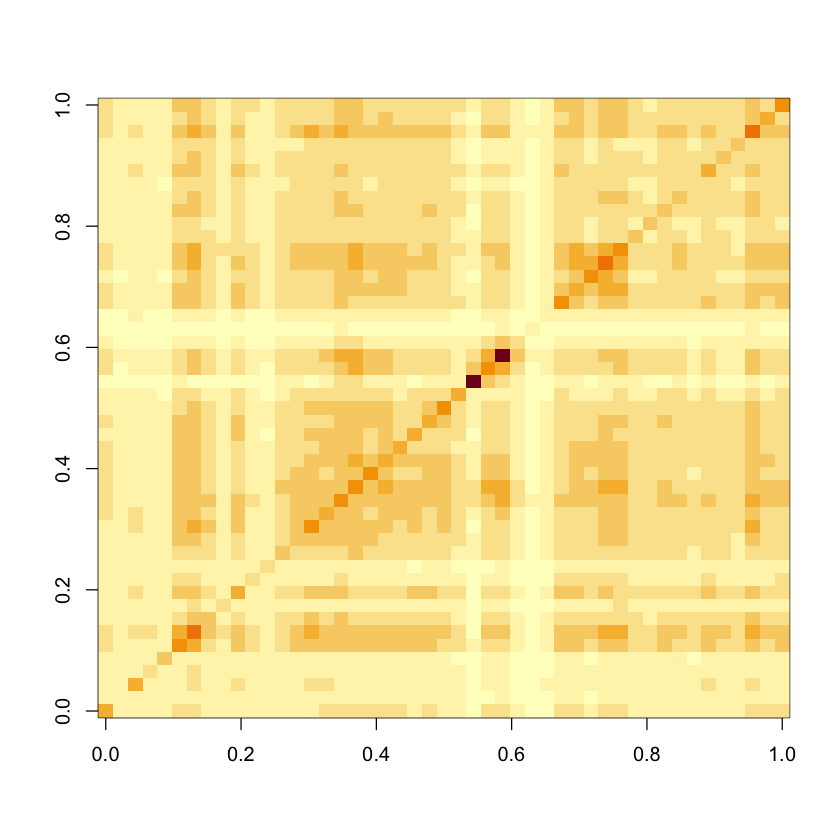

In [30]:
ix_maxvar <- which.max(apply(ff48, 2, var))
ff47 <- ff48 %>% select(-names(ix_maxvar))
boxplot(apply(ff47, 2, var))
image(cov(ff47))

In [38]:
### divide data set into subsets of about the same size, training and test:
trainix <- which((1:nrow(ff47)) %% 2 == 0) 
testix <- setdiff(1:nrow(ff47), trainix)
ff47_train <- ff47[trainix,]
ff47_test <- ff47[testix,]

In [49]:
# shrinkage target: we use the approach described in Ledoit and Wolf (2020):
# "The Power of (Non)-Linear Shrinking: A review and guide to covariance
# matrix estimation", Section 2. 

# Step 1: compute mean returns for each time period, and the variance sigma0 over all these returns
# Step 2: linearly regress stock returns on the mean returns, stock-by-stock. Extract the slopes and regression variances, denoted by beta and delta.
# Step 3: construct covariance matrix estimator as \hat{\Sigma} = sigma_0 beta * beta^T + \text{diag}(delta)

# Step 1:
av_ret <- apply(ff47_train, 1, mean)
sigma_0 <- var(av_ret)

beta <- apply(ff47_train, 2, function(z) coef(lm(z ~ av_ret))[2])  
delta <- apply(ff47_train, 2, function(z) summary(lm(z ~ av_ret))$sig)^2 

T <- sigma_0 * (beta %o% beta) + diag(delta)

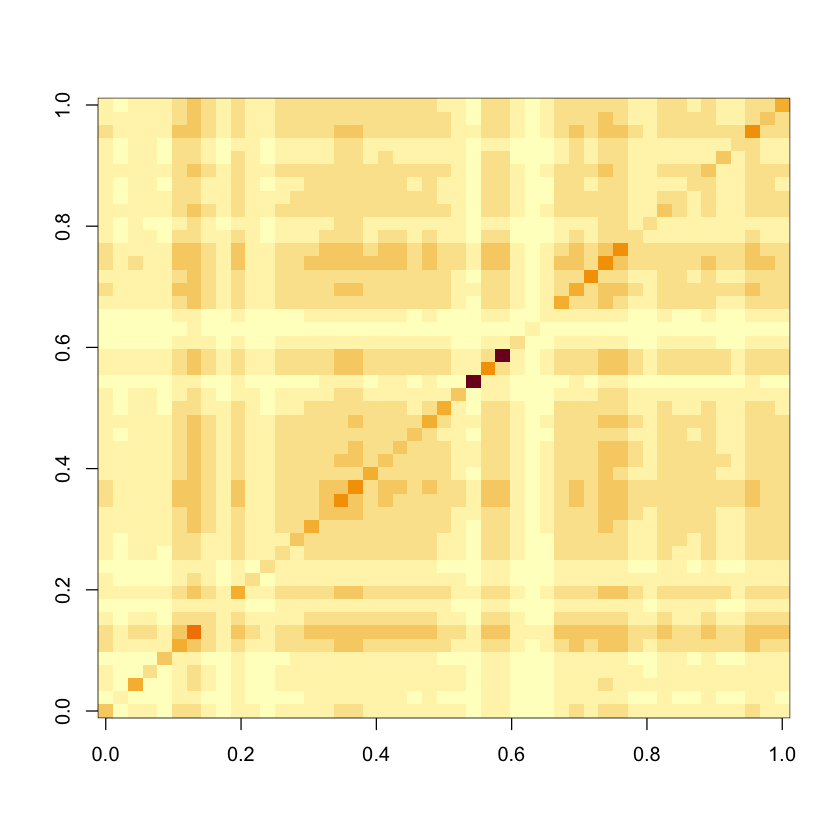

In [50]:
image(T) # the target looks quite reasonable compared to the full covariance matrix shown above

In [67]:
# trace test error as a function of the parameter lambda -- Stein loss (up to constants)
loss <- function(S0, Shatinv){
    d <- ncol(S0)
    sum(c(Shatinv) * c(S0))/d - (1/d) * determinant(Shatinv, log = TRUE)$modulus
}

lambdagrid <- seq(from = 0.01, to = 0.99, by = 0.01)
err <- numeric(length(lambdagrid))
# strictly speaking, we are not supposed to use any information from the test set when unknown parameters are concerned. 
# Thus, we estimate the   
Stest <- crossprod(scale(ff47_test, center = colMeans(ff47_train), scale = FALSE))/nrow(ff47_test)
Strain <- cov(ff47_train)
for(i in 1:length(lambdagrid)){

    lambda <- lambdagrid[i]
    err[i] <- loss(Stest, solve((1-lambda)*Strain + lambda*T))
    
}    

[1] 0.33

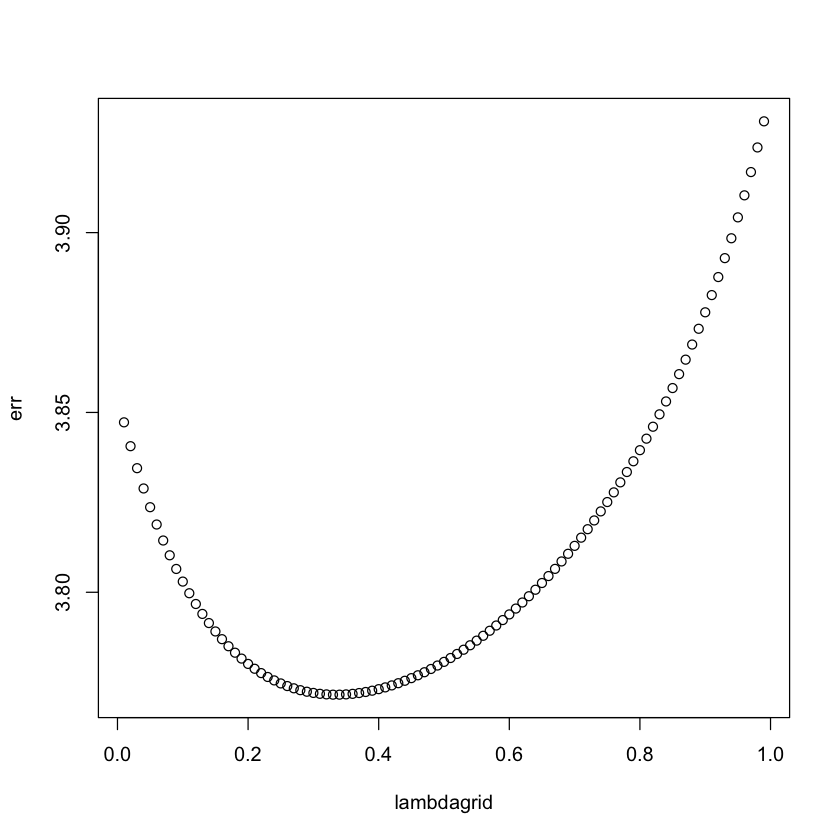

In [72]:
plot(lambdagrid, err)
lambdagrid[which.min(err)] # optimal lambda

In [80]:
lambdastar = lambdagrid[which.min(err)] 
Sigmahat = lambdastar*T + (1-lambdastar)*Strain 

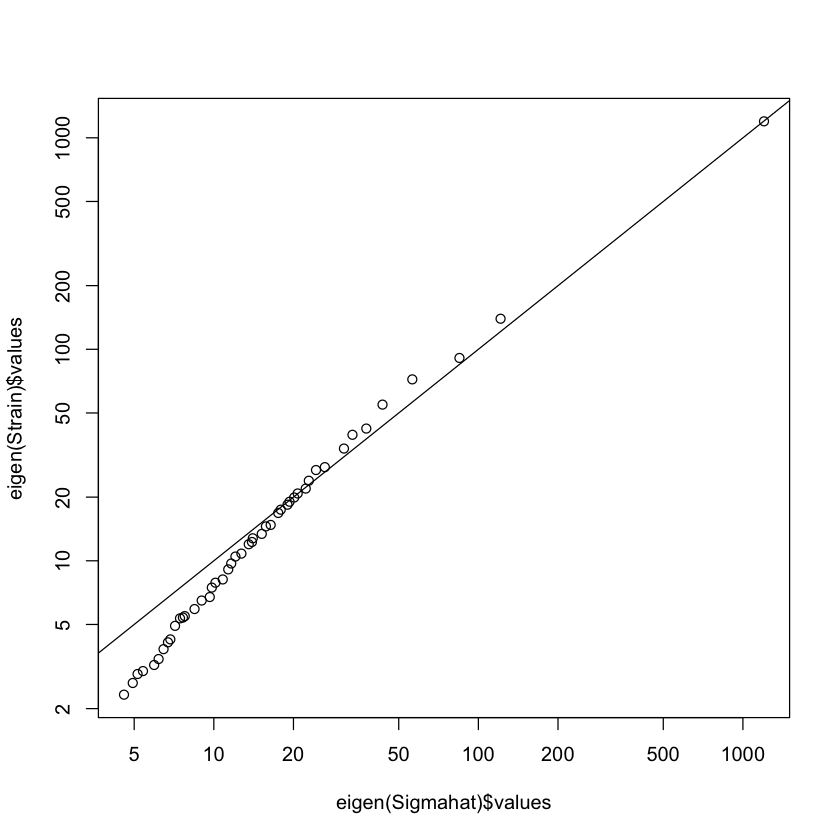

In [81]:
# Sigmahat is a much better conditioned estimator than the plain sample covariance matrix 
plot(eigen(Sigmahat)$values, eigen(Strain)$values,log = "xy")
abline(0,1)

In [82]:
summary(eigen(Sigmahat)$values)
summary(eigen(Strain)$values)
kappa(Sigmahat) # condition number: ratio largest/smallest eigenvalue
kappa(Strain) 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   4.576    7.703   13.553   44.607   21.500 1201.500 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   2.328    5.432   11.977   44.584   21.381 1196.298 

[1] 81.89137

[1] 175.1131